Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from sklearn.model_selection import train_test_split,cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] =(10,5)
pd.set_option("display.width",140); pd.set_option("display.max_columns", 40)
RANDOM_STATE =42

Load the dataset and perform EDA

In [2]:
df = pd.read_csv("house_price_50k.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
(df.isnull().sum()/len(df))*100
df.duplicated().sum()
df.describe()
df.describe(include="all")
df.select_dtypes(include=np.number).columns
df.select_dtypes(include="object").columns

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density    50000 no

Index(['location', 'income_level'], dtype='str')

House Price Distribution

In [3]:
df.columns.tolist()

['area',
 'bedrooms',
 'bathrooms',
 'floors',
 'age',
 'distance',
 'garage',
 'parking',
 'garden',
 'security',
 'school_nearby',
 'hospital_nearby',
 'shopping_mall_nearby',
 'public_transport',
 'crime_rate',
 'population_density',
 'location',
 'income_level',
 'price']

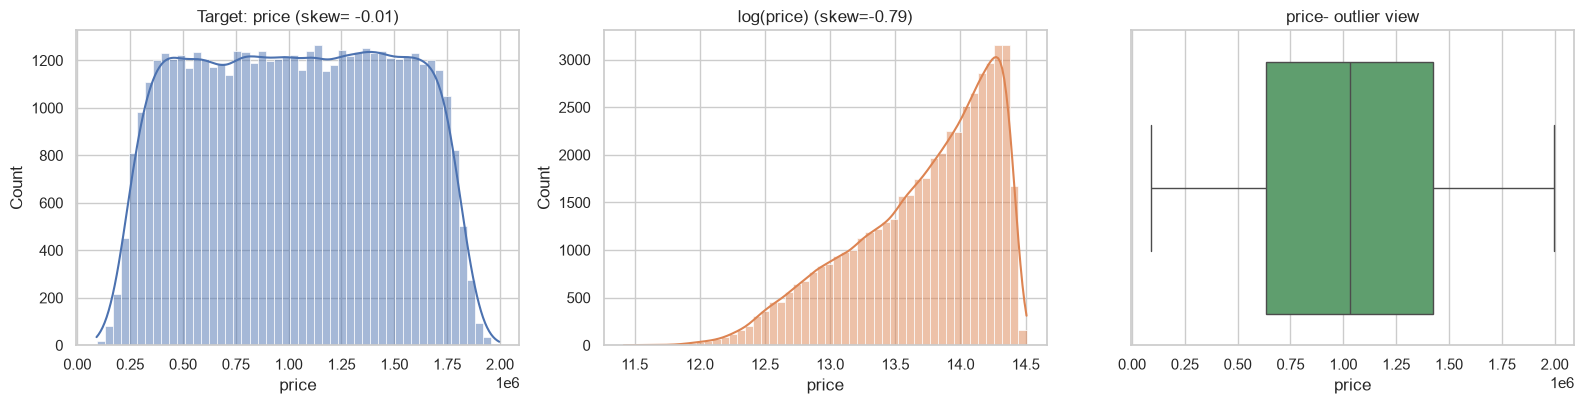

price: mean 1,030,261 | median1,031,763 | std458,020


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color= "#4C72B0")
axes[0].set_title(f"Target: price (skew= {df['price'].skew():.2f})")
sns.histplot(np.log(df['price']), bins=50, kde=True, ax=axes[1], color= "#DD8452")
axes[1].set_title(f"log(price) (skew={np.log(df['price']).skew():.2f})")
sns.boxplot(x=df['price'], ax=axes[2], color="#55A868")
axes[2].set_title("price- outlier view")
plt.tight_layout(); plt.show()
print("price: mean {:,.0f} | median{:,.0f} | std{:,.0f}".format(df['price'].mean(), df['price'].median(), df['price'].std()))


Observation:The price distribution is nearly symmetric with very low skewness.Mean and median are nearly the same, with no major outliers.

Feature Selection Reasoning Before Modelling

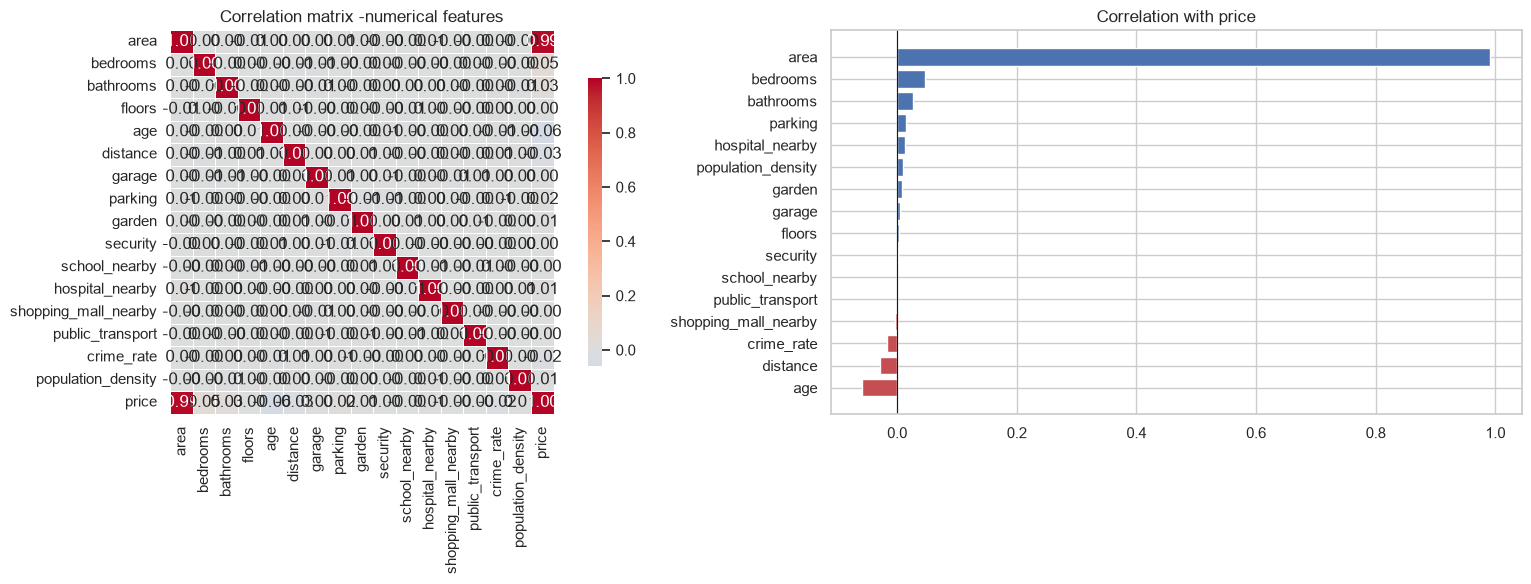

area                    0.991
bedrooms                0.047
bathrooms               0.026
parking                 0.015
hospital_nearby         0.014
population_density      0.011
garden                  0.009
garage                  0.005
floors                  0.003
security                0.002
school_nearby          -0.000
public_transport       -0.001
shopping_mall_nearby   -0.003
crime_rate             -0.017
distance               -0.028
age                    -0.059
Name: price, dtype: float64


In [5]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()
fig, axes = plt.subplots(1,2, figsize=(17,6))
sns.heatmap(corr , annot=True,fmt=".2f", cmap="coolwarm", center=0, ax=axes[0],square=True, linewidth=.4, cbar_kws={"shrink": .75})
axes[0].set_title("Correlation matrix -numerical features")
Price_corr = corr["price"].drop("price").sort_values()
axes[1].barh(Price_corr.index, Price_corr.values, color=["#C44E52" if v <0 else "#4C72B0" for v in Price_corr.values])

axes[1].set_title("Correlation with price"); axes[1].axvline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()
print(corr["price"].drop("price").sort_values(ascending=False).round(3))

Observation: Area has the strongest positive correlation with price.Most other features show very weak correlation with price.

Missing values and One-Hot Encoding

In [6]:
data = df.copy()
# --- missing values, with a stated reason for each choice ---
data["area"] = data["area"].fillna(data["area"].median())
data["parking"] = data["parking"].fillna(0)
if "heating" in data:
    data["heating"] = data["heating"].fillna(data["heating"].mode()[0])
print("Nulls remaining:", data.isna().sum().sum())
cat_cols = data.select_dtypes(include=["object","category"]).columns.tolist()
print("Categorical columns:", cat_cols)
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
data = data.astype(float)
print(f"\ncolumns:{df.shape[1]} - {data.shape[1]} after encoding")    


Nulls remaining: 0
Categorical columns: ['location', 'income_level']

columns:19 - 21 after encoding


Train/test split and model training

In [7]:
X = data.drop(columns="price")
y = data["price"]
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.20, random_state=RANDOM_STATE)
print(f"train: {X_train.shape} | test: {X_test.shape}")
lin = LinearRegression()
lin.fit(X_train, y_train)

lin_log = LinearRegression()
lin_log.fit(X_train, np.log1p(y_train))

print("\nModels fitted: LinearRegression on price, and o log(price)")
print("Intercept:", round(lin.intercept_, 2))

train: (40000, 20) | test: (10000, 20)

Models fitted: LinearRegression on price, and o log(price)
Intercept: 50118.15


Evaluation - MSE,RMSE,R^2

In [8]:
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mean_absolute_error(y_true, y_pred), "R2": r2_score(y_true, y_pred), "MAPE %": np.mean(np.abs((y_true - y_pred) / y_true))*100}
y_pred = lin.predict(X_test)
y_pred_log = np.exp(lin_log.predict(X_test))
rows = [evaluate("Linear Regression (price)", y_test, y_pred), evaluate("Linear Regression (Log price)", y_test, y_pred_log)]
res = pd.DataFrame(rows).set_index("Model")
print(res.round(3).to_string(float_format=lambda v: f"{v:,.3f}"))
cv = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state= RANDOM_STATE), scoring="r2")
print(f"\n5-fold CV R2: {cv.mean():.4f}(+/- {cv.std():.4f})")
print(f"Train R2: {lin.score(X_train, y_train):.4f} | Test R2: {lin.score(X_test, y_test):.4f}")

                                             MSE        RMSE         MAE    R2  MAPE %
Model                                                                                 
Linear Regression (price)        397,637,450.315  19,940.849  15,954.173 0.998   2.086
Linear Regression (Log price) 19,182,995,876.491 138,502.693 106,119.186 0.909  11.771

5-fold CV R2: 0.9981(+/- 0.0000)
Train R2: 0.9981 | Test R2: 0.9981


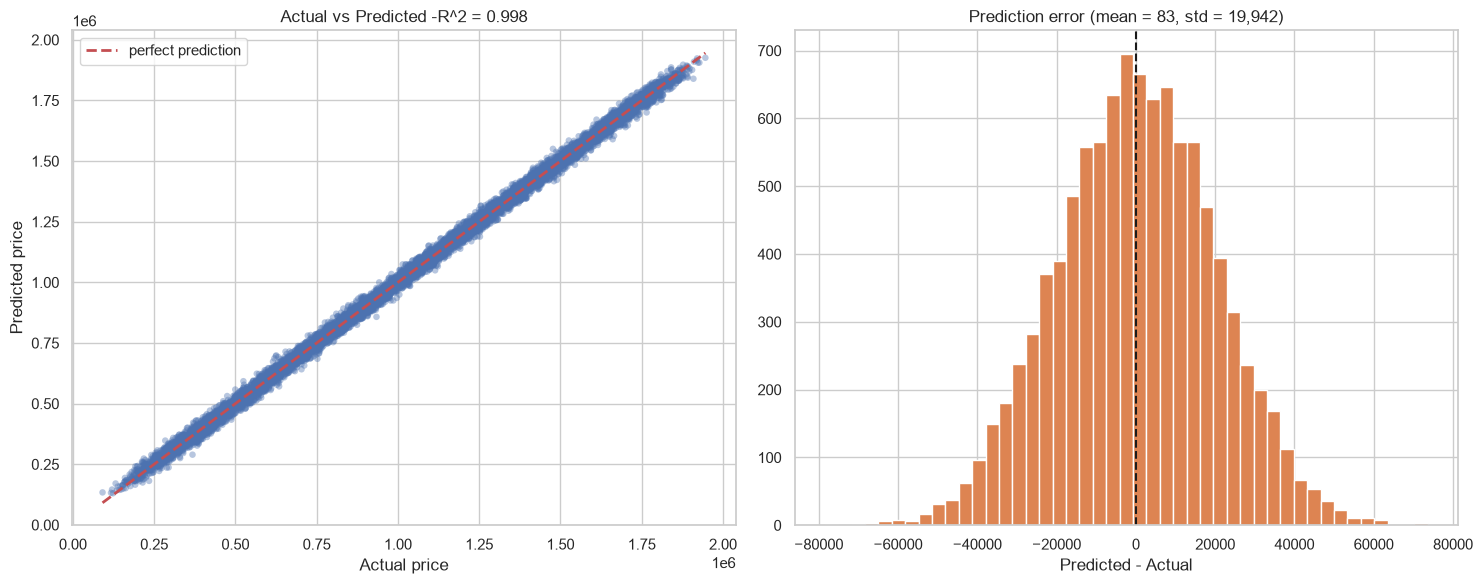

Predictions within 10% of actual: 98.3%
Predictions within 20% of actual: 99.9%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(),y_pred.max())]
axes[0].scatter(y_test, y_pred, alpha=.4, s=22, color="#4C72B0", edgecolor="none")
axes[0].plot(lims, lims, "r--", lw=2, label="perfect prediction")
axes[0].set_xlabel("Actual price"); axes[0].set_ylabel("Predicted price")
axes[0].set_title(f"Actual vs Predicted -R^2 = {r2_score(y_test, y_pred):.3f}")
axes[0].legend()
err = y_pred - y_test
axes[1].hist(err, bins=45, color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="k" ,ls="--")
axes[1].set_title(f"Prediction error (mean = {err.mean():.0f}, std = {err.std():,.0f})")
axes[1].set_xlabel("Predicted - Actual")
plt.tight_layout(); plt.show()
within = lambda p: np.mean(np.abs(err) / y_test < p)
print(f"Predictions within 10% of actual: {within(.10):.1%}")
print(f"Predictions within 20% of actual: {within(.20):.1%}")

Observation: Actual and predicted prices are very closely aligned, showing excellent model performance(R2 = 0.998)
prediction errors are small and centered around zero,indicating accurate predictions.

Residual analysis

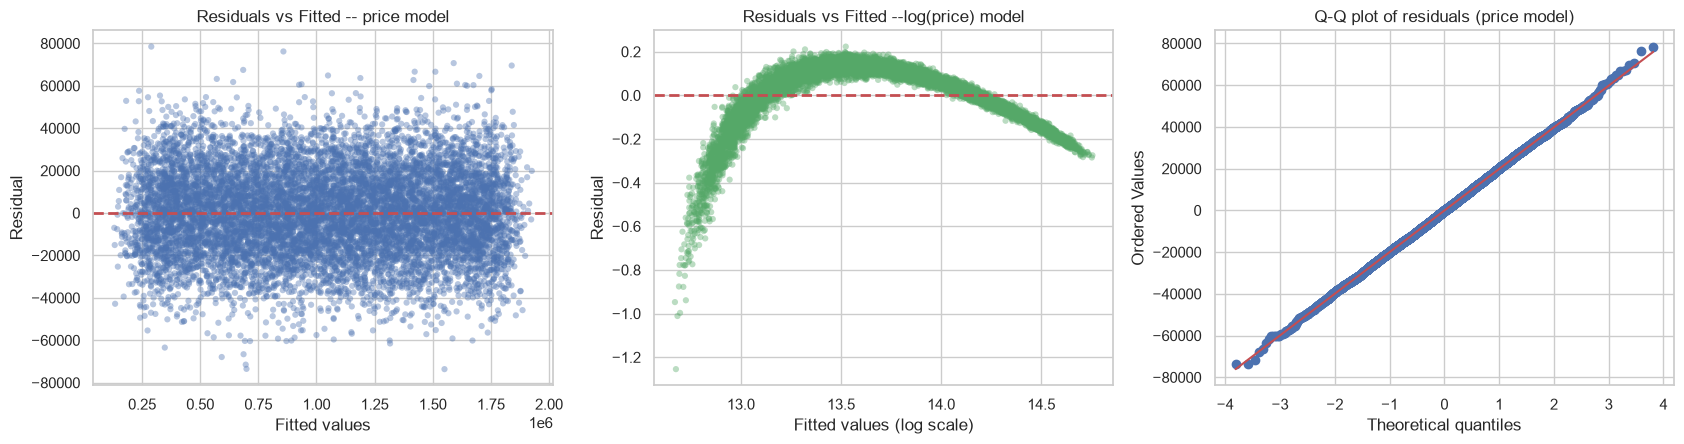

Residual mean:-82.9 (should be ~0)
Residual std : 19,941.7
Skew:0.019 | Kurtosis: -0.037
Corr(|residual|, fitted): -0.008 (near 0 = homoscedastic)


In [10]:
residuals = y_test - y_pred
residuals_log = np.log(y_test) - lin_log.predict(X_test)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].scatter(y_pred, residuals, alpha=.4, s=20, color="#4C72B0", edgecolor="none")
axes[0].axhline(0, color="r", ls="--", lw=2)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted -- price model")
axes[1].scatter(lin_log.predict(X_test), residuals_log, alpha=.4, s=20, color="#55A868", edgecolor="none")
axes[1].axhline(0, color="r", ls="--", lw=2)
axes[1].set_xlabel("Fitted values (log scale)"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted --log(price) model")

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals (price model)")
plt.tight_layout(); plt.show()
print("Residual mean:{:,.1f} (should be ~0)".format(residuals.mean()))
print("Residual std : {:,.1f}".format(residuals.std()))
print("Skew:{:.3f} | Kurtosis: {:.3f}".format(stats.skew(residuals), stats.kurtosis(residuals)))
corr_rf = np.corrcoef(y_pred, np.abs(residuals))[0,1]
print(f"Corr(|residual|, fitted): {corr_rf:.3f} (near 0 = homoscedastic)")

Observation: Residuals are centered around zero with very low skewness. Residual spread is fairly constant,no major heteroscedasticity.

Coefficient analysis

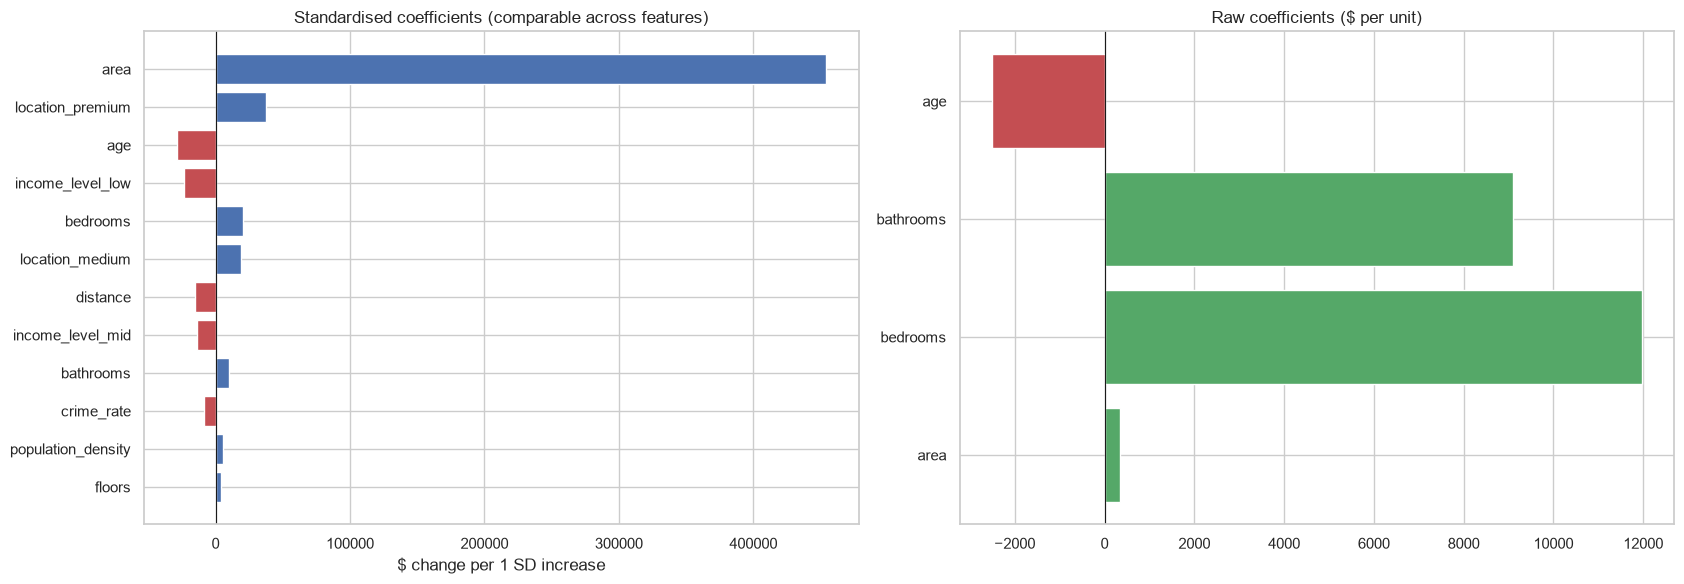

           feature  coefficient  std_coefficient
              area       350.10        454026.97
  location_premium     80256.43         37803.82
               age     -2504.77        -28938.05
  income_level_low    -50077.17        -23588.24
          bedrooms     11961.86         20502.29
   location_medium     40240.01         18984.09
          distance     -1792.68        -14988.11
  income_level_mid    -29816.08        -14049.01
         bathrooms      9108.38         10161.05
        crime_rate     -3062.80         -8794.43
population_density         2.00          5746.34
            floors      4992.86          4072.21


In [11]:
coefs = pd.DataFrame({"feature": X.columns, "coefficient": lin.coef_})
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
lin_std = LinearRegression().fit(Xs_train, y_train)
coefs["std_coefficient"] = lin_std.coef_
coefs["abs_std"] = coefs["std_coefficient"].abs()
coefs = coefs.sort_values("abs_std", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(17,6))
top = coefs.head(12).iloc[::-1]
axes[0].barh(top["feature"], top["std_coefficient"],color=["#C44E52" if v < 0 else "#4C72B0" for v in top["std_coefficient"]])
axes[0].axvline(0, color="k", lw=.8)
axes[0].set_title("Standardised coefficients (comparable across features)")
axes[0].set_xlabel("$ change per 1 SD increase")

raw = coefs.set_index("feature").loc[[c for c in ["area", "bedrooms","bathrooms", "age","garage_spaces","condition","lot_size"] if c in coefs["feature"].values]]

axes[1].barh(raw.index, raw["coefficient"],color=["#C44E52" if v < 0 else "#55A868" for v in raw["coefficient"]])
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_title("Raw coefficients ($ per unit)")
plt.tight_layout(); plt.show()
print(coefs[["feature", "coefficient", "std_coefficient"]].head(12).round(2).to_string(index=False))


Observation: Area has the strongest positive effect on price. Age and some other features have smaller or negative effects on price

In [12]:
TRUE_COEFS = {
    "area": 120,
    "bedrooms":9500,
    "bathrooms": 17000,
    "age": -1000,
    "garage_spaces": 1.5,
    "condition": 6200,
}

In [13]:
# Because the synthetic data came from a known equation, the revoverd coefficients
# can be checked against the truth. (Skipped automatically on a real dataset)
if TRUE_COEFS:
    chk = (coefs.set_index("feature").reindex(list(TRUE_COEFS))[["coefficient"]].rename(columns={"coefficient": "estimated"}))
    chk["true"] = pd.Series(TRUE_COEFS)
    chk["error %"] = ((chk["estimated"] - chk["true"]) / chk["true"] * 100).round(1)
    print("Recovered vs. true coefficients:\n")
    print(chk.round(2).to_string())
else:
    print("Real dataset in use - no ground-truth coefficients to compare against.")

Recovered vs. true coefficients:

               estimated     true  error %
feature                                   
area              350.10    120.0    191.8
bedrooms        11961.86   9500.0     25.9
bathrooms        9108.38  17000.0    -46.4
age             -2504.77  -1000.0    150.5
garage_spaces        NaN      1.5      NaN
condition            NaN   6200.0      NaN


Bonus- Ridge and Lasso

In [14]:
alphas = np.logspace(-2, 4,60)

pipelines = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (CV alpha)": make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5)),
    "Lasso (CV alpha)": make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=5000))

    }

rows = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    r = evaluate(name, y_test,pred)
    cvs = cross_val_score(pipe, X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
    r["CV R2"] = cvs.mean()
    rows.append(r)

comparison = pd.DataFrame(rows).set_index("Model")
print(comparison.round(4).to_string(float_format=lambda v: f"{v:,.4f}"))

ridge_alpha = pipelines["Ridge (CV alpha)"].named_steps["ridgecv"].alpha_
lasso_model = pipelines["Lasso (CV alpha)"].named_steps["lassocv"]

lasso_alpha = lasso_model.alpha_
lasso_coef = lasso_model.coef_
print(f"\nChosen alpha - Ridge: {ridge_alpha:.3f} | Lasso: {lasso_alpha:.3f}")
print(f"Features zeroed out by Lasso:" f"{(lasso_coef ==0).sum()} / {len(lasso_coef)}")
if (lasso_coef == 0).sum():
    print("Dropped:", list(X.columns[lasso_coef == 0]))

                               MSE        RMSE         MAE     R2  MAPE %  CV R2
Model                                                                           
Linear Regression 397,637,450.3150 19,940.8488 15,954.1727 0.9981  2.0858 0.9981
Ridge (CV alpha)  397,636,994.4782 19,940.8374 15,954.1664 0.9981  2.0858 0.9981
Lasso (CV alpha)  397,634,178.0399 19,940.7667 15,954.0964 0.9981  2.0858 0.9981

Chosen alpha - Ridge: 0.131 | Lasso: 0.855
Features zeroed out by Lasso:0 / 20


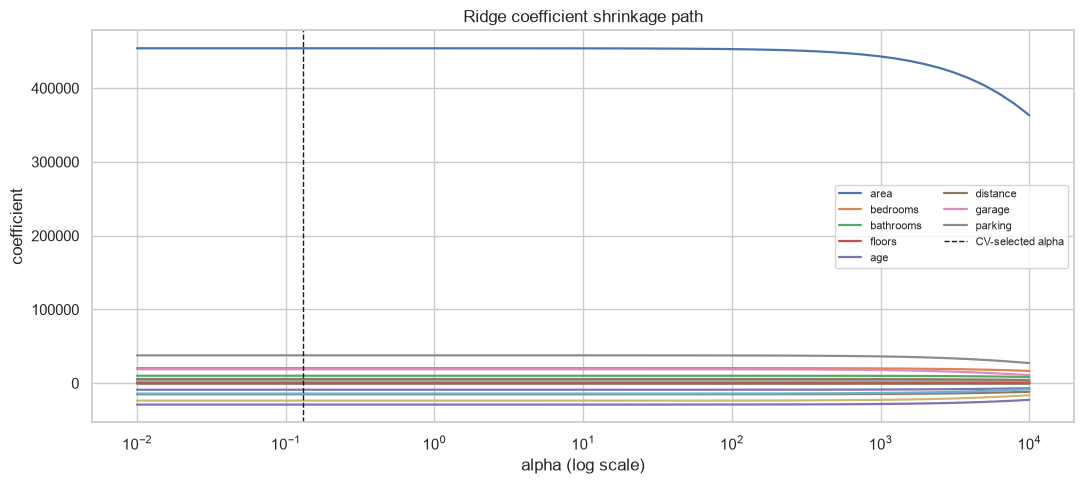

In [15]:
coef_path = []
Xs = StandardScaler().fit_transform(X_train)
for a in alphas:
    coef_path.append(Ridge(alpha=a).fit(Xs, y_train).coef_)
coef_path = np.array(coef_path) 

plt.figure(figsize=(11, 5))
for i, col in enumerate(X.columns):
    plt.plot(alphas, coef_path[:, i], lw=1.6, label=col if i < 8 else None)
plt.xscale("log");plt.axvline(ridge_alpha, color="k", ls="--",lw=1, label="CV-selected alpha") 
plt.xlabel("alpha (log scale)"); plt.ylabel("coefficient") 
plt.title("Ridge coefficient shrinkage path") 
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show() 

Observation: The area coefficient remains strongly positive,showing its major impact on price.
As alpha increases ,coefficients shrink, showing Ridge regularization reduces model complexity